In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import phik

In [3]:
# load the data
df = pd.read_csv("../../../Datasets/adult.csv")


# let's quickly see the first 5 rows of data
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


##### <b> <u>Step 2b</u>: Multicollinearity & redundancy </b> 

Taken the help of AI to generate me the following visuals

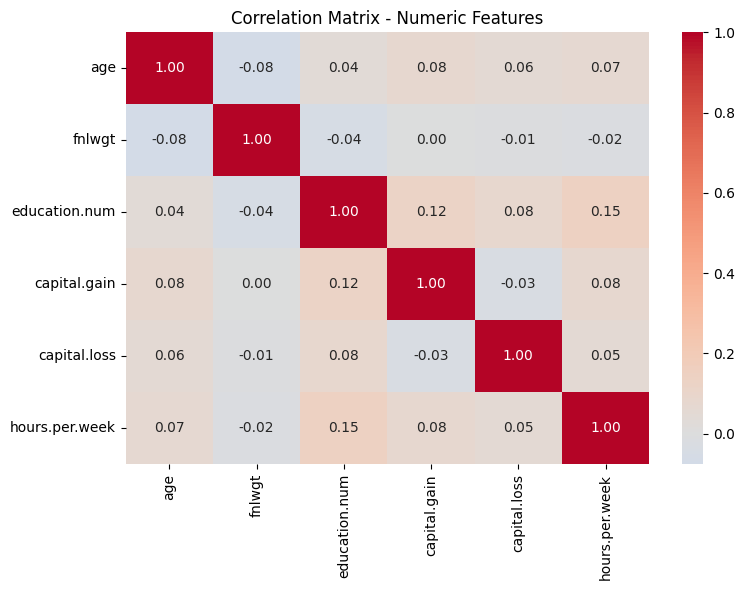

In [4]:
numeric_cols = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

# 1. Correlation matrix
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Numeric Features')
plt.tight_layout()
plt.show()

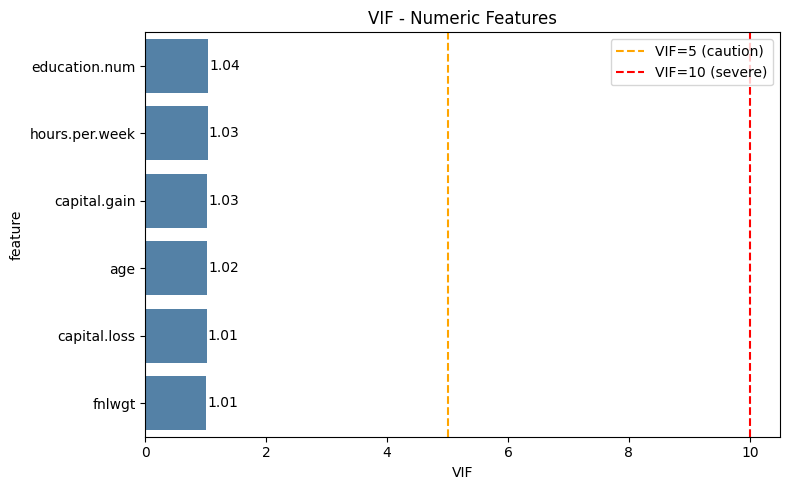

In [5]:
# 2. VIF chart
X = df[numeric_cols]
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
vif_data = vif_data.sort_values('VIF', ascending=False)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=vif_data, x='VIF', y='feature', color='steelblue')
for i, v in enumerate(vif_data['VIF']):
    ax.text(v + 0.02, i, f'{v:.2f}', va='center')
plt.axvline(5, color='orange', linestyle='--', label='VIF=5 (caution)')
plt.axvline(10, color='red', linestyle='--', label='VIF=10 (severe)')
plt.title('VIF - Numeric Features')
plt.legend()
plt.tight_layout()
plt.show()

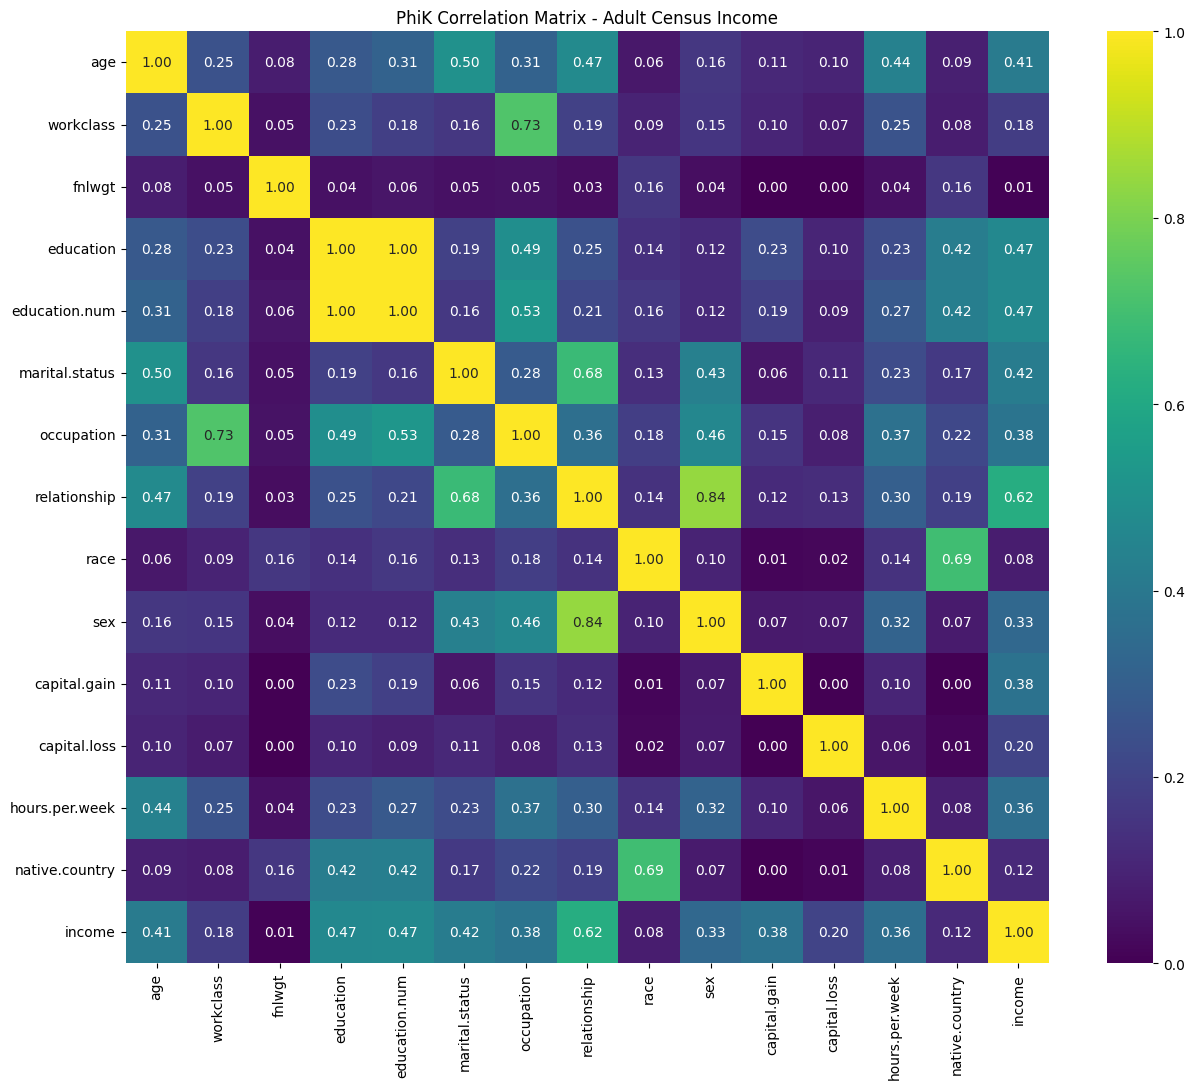

In [6]:
# 3. PhiK matrix (categorical + numeric combined)
cols = ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status',
        'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss',
        'hours.per.week', 'native.country', 'income']
interval_cols = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

phik_df = df[cols].phik_matrix(interval_cols=interval_cols)
plt.figure(figsize=(13, 11))
sns.heatmap(phik_df, annot=True, fmt='.2f', cmap='viridis')
plt.title('PhiK Correlation Matrix - Adult Census Income')
plt.tight_layout()
plt.show()

In [7]:
pd.set_option('display.float_format', lambda x: '%.1f' % x)

import warnings
warnings.filterwarnings("ignore")

from statsmodels.stats.outliers_influence import variance_inflation_factor

# explicitly select only the numeric features (categorical columns excluded,
# since VIF requires purely numeric input)
numeric_cols = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
X = df[numeric_cols]

# VIF dataframe
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                    for i in range(len(X.columns))]

vif_data.sort_values(by="VIF", ascending=False)

,feature,VIF
2,education.num,1.0
5,hours.per.week,1.0
3,capital.gain,1.0
0,age,1.0
4,capital.loss,1.0
1,fnlwgt,1.0


##### <b> <u>Step 2c</u>: High cardinality</b> 

In [ ]:
# Let's check the number of unique values in each categorical column

cat_cols = ['workclass','education','marital.status','occupation','relationship','race','sex','native.country']
total_rows = len(df)

for col in cat_cols:
    n_unique = df[col].nunique()
    pct = 100*n_unique/total_rows
    print(f'{col:18s} {n_unique:10d} {pct:12.2f}%')
print()

workclass                   9         0.03%
education                  16         0.05%
marital.status              7         0.02%
occupation                 15         0.05%
relationship                6         0.02%
race                        5         0.02%
sex                         2         0.01%
native.country             42         0.13%



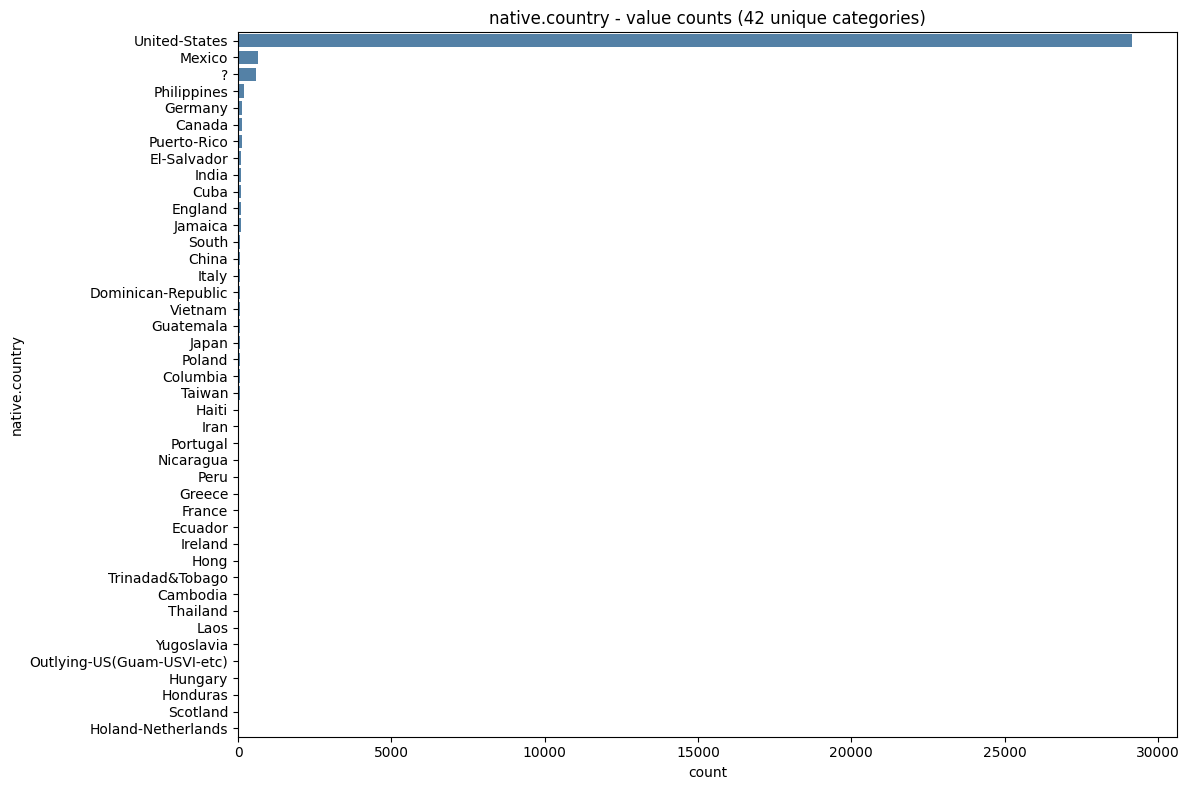

In [14]:
# Visualize the distribution of values in the 'native.country' column
counts = df['native.country'].value_counts()
# show US separately, then rest
plt.figure(figsize=(12,8))
sns.barplot(x=counts.values, y=counts.index, color='steelblue')
plt.xlabel('count')
plt.title('native.country - value counts (42 unique categories)')
plt.tight_layout()
plt.show()
plt.close()